# Noise CQT extraction (ESC-50)

Extract Constant-Q features from selected ESC-50 noise clips using the **same CQT parameters** as chord features (`216 × 188`, 48 kHz, hop 512, C1–C7).

Output is a reusable noise bank npz under `training/features/noise/` for later power-domain mixing onto **vivo / thinkpad** (not training) chord features.

Configure class filters in the config cell only.

## Config

In [1]:
import librosa
from os import path
import pandas as pd
from IPython.display import display

# --- noise bank config (change this cell for different subsets) ---
NOISE_SOURCE = "esc-50"
ESC50_ROOT = path.normpath("../../noises/esc-50")
ESC50_META = path.join(ESC50_ROOT, "meta", "esc50.csv")
ESC50_AUDIO = path.join(ESC50_ROOT, "audio")

# ESC-50 major groups (target id ranges)
# animals 0-9 | natural 10-19 | human 20-29 | interior_domestic 30-39 | exterior_urban 40-49
MAJOR_GROUPS = ["interior_domestic"]

# Optional fine filter. None = all classes inside MAJOR_GROUPS.
# Example: ["vacuum_cleaner", "clock_tick", "keyboard_typing"]
CATEGORIES = None

# Output tag used in the npz filename when FEATURES_NAME is None
BANK_TAG = "interior_domestic"
FEATURES_NAME = None  # e.g. "esc50-interior_domestic.npz"; None -> auto from BANK_TAG

FEATURES_DIR = path.normpath("../../features/noise")
if FEATURES_NAME is None:
    FEATURES_NAME = f"esc50-{BANK_TAG}.npz"
FEATURES_OUT = path.join(FEATURES_DIR, FEATURES_NAME)
CHECKPOINT_PATH = FEATURES_OUT + ".ckpt.npz"

# Set True only when you intentionally want to recompute from scratch
FORCE_REEXTRACT = False

# How to pick a fixed 2s segment from longer clips (ESC-50 is 5s).
# - "max_energy": sliding window with highest RMS energy (avoids quiet intros)
# - "start": first AUDIO_MIN_DURATION seconds only
SEGMENT_MODE = "max_energy"
SEGMENT_HOP_S = 0.25  # hop for max_energy search

# --- CQT params: must match chord extraction (training/vivo/thinkpad) ---
AUDIO_MIN_DURATION = 2  # seconds
AUDIO_SAMPLE_RATE = 48_000
CQT_HOP_LENGTH = 512
CQT_OCTAVES = 6
CQT_BINS_PER_OCTAVE = 36
CQT_FEATURE_FRAMES = round(AUDIO_MIN_DURATION * AUDIO_SAMPLE_RATE / CQT_HOP_LENGTH)
CQT_FMIN = librosa.note_to_hz("C1")

MAJOR_TARGET_RANGES = {
    "animals": range(0, 10),
    "natural_soundscapes_water": range(10, 20),
    "human_non_speech": range(20, 30),
    "interior_domestic": range(30, 40),
    "exterior_urban": range(40, 50),
}

config_df = pd.DataFrame(
    [
        {"key": "noise_source", "value": NOISE_SOURCE},
        {"key": "major_groups", "value": MAJOR_GROUPS},
        {"key": "categories", "value": CATEGORIES},
        {"key": "features_out", "value": FEATURES_OUT},
        {"key": "checkpoint", "value": CHECKPOINT_PATH},
        {"key": "force_reextract", "value": FORCE_REEXTRACT},
        {"key": "segment_mode", "value": SEGMENT_MODE},
        {"key": "segment_hop_s", "value": SEGMENT_HOP_S},
        {"key": "feature_bins", "value": CQT_BINS_PER_OCTAVE * CQT_OCTAVES},
        {"key": "feature_frames", "value": CQT_FEATURE_FRAMES},
        {"key": "fmin_hz", "value": float(CQT_FMIN)},
    ]
).set_index("key")
display(config_df)

,value
key,
noise_source,esc-50
major_groups,[interior_domestic]
categories,None
features_out,../../features/noise/esc50-interior_domestic.npz
checkpoint,../../features/noise/esc50-interior_domestic.n...
force_reextract,False
segment_mode,max_energy
segment_hop_s,0.25
feature_bins,216


## Select clips

In [2]:
import csv
import pandas as pd
from IPython.display import display

unknown = set(MAJOR_GROUPS) - set(MAJOR_TARGET_RANGES)
if unknown:
    raise ValueError(f"Unknown MAJOR_GROUPS: {sorted(unknown)}")

allowed_targets = set()
for group in MAJOR_GROUPS:
    allowed_targets.update(MAJOR_TARGET_RANGES[group])

with open(ESC50_META, newline="") as f:
    rows = list(csv.DictReader(f))

selected = []
missing = []
for row in rows:
    target = int(row["target"])
    category = row["category"]
    if target not in allowed_targets:
        continue
    if CATEGORIES is not None and category not in CATEGORIES:
        continue
    audio_path = path.join(ESC50_AUDIO, row["filename"])
    if not path.isfile(audio_path):
        missing.append({"filename": row["filename"], "path": audio_path})
        continue
    selected.append({
        "filename": row["filename"],
        "path": audio_path,
        "category": category,
        "target_id": target,
        "fold": int(row["fold"]),
        "major": next(
            name for name, r in MAJOR_TARGET_RANGES.items() if target in r
        ),
    })

if not selected:
    raise RuntimeError("No clips selected — check MAJOR_GROUPS / CATEGORIES")

selected_df = pd.DataFrame(selected)
summary_df = pd.DataFrame(
    [{
        "n_clips": len(selected_df),
        "n_classes": selected_df["category"].nunique(),
        "n_missing": len(missing),
        "majors": sorted(selected_df["major"].unique()),
    }]
)
class_counts_df = (
    selected_df.groupby(["major", "target_id", "category"], as_index=False)
    .size()
    .rename(columns={"size": "n"})
    .sort_values(["major", "target_id"])
    .reset_index(drop=True)
)

display(summary_df)
display(class_counts_df)
if missing:
    display(pd.DataFrame(missing))

,n_clips,n_classes,n_missing,majors
0,400,10,0,[interior_domestic]


,major,target_id,category,n
0,interior_domestic,30,door_wood_knock,40
1,interior_domestic,31,mouse_click,40
2,interior_domestic,32,keyboard_typing,40
3,interior_domestic,33,door_wood_creaks,40
4,interior_domestic,34,can_opening,40
5,interior_domestic,35,washing_machine,40
6,interior_domestic,36,vacuum_cleaner,40
7,interior_domestic,37,clock_alarm,40
8,interior_domestic,38,clock_tick,40
9,interior_domestic,39,glass_breaking,40


## Extract CQT

In [3]:
from os import makedirs, remove
from tqdm.notebook import tqdm
import numpy as np
import pandas as pd
from IPython.display import display
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


def preprocess(cqt):
    """Truncate / zero-pad to fixed frame length (same as chord extractors)."""
    if cqt.shape[1] < CQT_FEATURE_FRAMES:
        pad_width = CQT_FEATURE_FRAMES - cqt.shape[1]
        cqt = np.pad(cqt, pad_width=((0, 0), (0, pad_width)), mode="constant")
    else:
        cqt = cqt[:, :CQT_FEATURE_FRAMES]
    return cqt


def select_segment(y, sr):
    """Return (segment, start_sample) of length AUDIO_MIN_DURATION."""
    n_need = int(round(AUDIO_MIN_DURATION * sr))
    if len(y) <= n_need:
        if len(y) < n_need:
            y = np.pad(y, (0, n_need - len(y)))
        return y[:n_need], 0

    if SEGMENT_MODE == "start":
        return y[:n_need], 0

    if SEGMENT_MODE != "max_energy":
        raise ValueError(f"Unknown SEGMENT_MODE={SEGMENT_MODE!r}")

    hop = max(1, int(round(SEGMENT_HOP_S * sr)))
    best_start = 0
    best_energy = -1.0
    for start in range(0, len(y) - n_need + 1, hop):
        energy = float(np.dot(y[start : start + n_need], y[start : start + n_need]))
        if energy > best_energy:
            best_energy = energy
            best_start = start
    end_start = len(y) - n_need
    energy = float(np.dot(y[end_start:], y[end_start:]))
    if energy > best_energy:
        best_start = end_start
    return y[best_start : best_start + n_need], best_start


def extract_cqt_features(audio_path):
    """CQT dB features — same CQT settings as chord notebooks.

    Audio is longer than 2s (ESC-50 = 5s). We cut a fixed 2s segment first
    (max-energy by default), then run CQT so quiet intros are not baked in.
    """
    try:
        y, sr = librosa.load(audio_path, sr=AUDIO_SAMPLE_RATE, mono=True)
        duration_s = len(y) / float(sr)
        y_seg, start = select_segment(y, sr)
        cqt = librosa.cqt(
            y=y_seg,
            sr=sr,
            fmin=CQT_FMIN,
            n_bins=CQT_BINS_PER_OCTAVE * CQT_OCTAVES,
            bins_per_octave=CQT_BINS_PER_OCTAVE,
            hop_length=CQT_HOP_LENGTH,
            window="hann",
        )
        cqt = np.abs(cqt)
        cqt = librosa.amplitude_to_db(cqt, ref=np.max)
        cqt = preprocess(cqt)
        meta = {
            "duration_s": duration_s,
            "segment_start_s": start / float(sr),
            "segment_mode": SEGMENT_MODE,
        }
        return cqt, meta
    except Exception as e:
        return None, {"error": str(e), "path": audio_path}


def save_checkpoint(payload, ckpt_path):
    np.savez_compressed(ckpt_path, **payload)


makedirs(FEATURES_DIR, exist_ok=True)
extract_errors = []

if path.isfile(FEATURES_OUT) and not FORCE_REEXTRACT:
    data = np.load(FEATURES_OUT, allow_pickle=True)
    skip_df = pd.DataFrame(
        [{
            "status": "skipped_cache",
            "features_out": FEATURES_OUT,
            "features_shape": data["features"].shape,
            "n_labels": int(data["labels"].shape[0]),
            "n_classes": int(len(np.unique(data["labels"]))),
        }]
    )
    display(skip_df)
else:
    features = []
    labels = []
    files = []
    target_ids = []
    majors = []
    folds = []
    durations_s = []
    segment_starts_s = []
    done = set()

    if path.isfile(CHECKPOINT_PATH) and not FORCE_REEXTRACT:
        ckpt = np.load(CHECKPOINT_PATH, allow_pickle=True)
        features = list(ckpt["features"])
        labels = list(ckpt["labels"].astype(str))
        files = list(ckpt["files"].astype(str))
        target_ids = list(ckpt["target_ids"])
        majors = list(ckpt["majors"].astype(str))
        folds = list(ckpt["folds"])
        durations_s = list(ckpt["durations_s"])
        segment_starts_s = list(ckpt["segment_starts_s"])
        done = set(files)
        display(pd.DataFrame([{"status": "resumed_checkpoint", "n_done": len(done), "path": CHECKPOINT_PATH}]))
    elif FORCE_REEXTRACT and path.isfile(CHECKPOINT_PATH):
        remove(CHECKPOINT_PATH)

    for item in tqdm(selected, desc=f"Extracting {BANK_TAG}"):
        key = item["filename"]
        if key in done:
            continue
        cqt, meta = extract_cqt_features(item["path"])
        if cqt is None:
            extract_errors.append(meta or {"path": item["path"], "error": "unknown"})
            continue
        features.append(cqt)
        labels.append(item["category"])
        files.append(key)
        target_ids.append(item["target_id"])
        majors.append(item["major"])
        folds.append(item["fold"])
        durations_s.append(meta["duration_s"])
        segment_starts_s.append(meta["segment_start_s"])
        done.add(key)

        if len(done) % 50 == 0:
            save_checkpoint(
                {
                    "features": np.asarray(features, dtype=np.float32),
                    "labels": np.asarray(labels),
                    "files": np.asarray(files),
                    "target_ids": np.asarray(target_ids, dtype=np.int32),
                    "majors": np.asarray(majors),
                    "folds": np.asarray(folds, dtype=np.int32),
                    "durations_s": np.asarray(durations_s, dtype=np.float32),
                    "segment_starts_s": np.asarray(segment_starts_s, dtype=np.float32),
                    "source": np.asarray(NOISE_SOURCE),
                    "bank_tag": np.asarray(BANK_TAG),
                },
                CHECKPOINT_PATH,
            )

    if not features:
        raise RuntimeError("No features extracted")

    payload = {
        "features": np.asarray(features, dtype=np.float32),
        "labels": np.asarray(labels),
        "files": np.asarray(files),
        "target_ids": np.asarray(target_ids, dtype=np.int32),
        "majors": np.asarray(majors),
        "folds": np.asarray(folds, dtype=np.int32),
        "durations_s": np.asarray(durations_s, dtype=np.float32),
        "segment_starts_s": np.asarray(segment_starts_s, dtype=np.float32),
        "source": np.asarray(NOISE_SOURCE),
        "bank_tag": np.asarray(BANK_TAG),
        "segment_mode": np.asarray(SEGMENT_MODE),
        "major_groups": np.asarray(MAJOR_GROUPS),
        "categories_filter": np.asarray(
            CATEGORIES if CATEGORIES is not None else ["__all__"]
        ),
    }
    np.savez_compressed(FEATURES_OUT, **payload)
    starts = payload["segment_starts_s"]
    save_df = pd.DataFrame(
        [{
            "status": "saved",
            "features_out": FEATURES_OUT,
            "n_samples": int(payload["features"].shape[0]),
            "features_shape": payload["features"].shape,
            "dtype": str(payload["features"].dtype),
            "segment_mode": SEGMENT_MODE,
            "duration_s_min": float(payload["durations_s"].min()),
            "duration_s_max": float(payload["durations_s"].max()),
            "segment_start_min": float(starts.min()),
            "segment_start_median": float(np.median(starts)),
            "segment_start_max": float(starts.max()),
            "n_shifted": int((starts > 0).sum()),
            "n_errors": len(extract_errors),
        }]
    )
    display(save_df)
    if path.isfile(CHECKPOINT_PATH):
        remove(CHECKPOINT_PATH)

if extract_errors:
    display(pd.DataFrame(extract_errors))

,status,features_out,features_shape,n_labels,n_classes
0,skipped_cache,../../features/noise/esc50-interior_domestic.npz,"(400, 216, 188)",400,10


## Verify

In [4]:
import pandas as pd
from IPython.display import display

data = np.load(FEATURES_OUT, allow_pickle=True)

meta_df = pd.DataFrame(
    [{
        "features_out": FEATURES_OUT,
        "features_shape": data["features"].shape,
        "dtype": str(data["features"].dtype),
        "n_labels": int(data["labels"].shape[0]),
        "n_classes": int(len(np.unique(data["labels"]))),
        "source": str(data["source"]) if "source" in data.files else None,
        "bank_tag": str(data["bank_tag"]) if "bank_tag" in data.files else None,
        "segment_mode": str(data["segment_mode"]) if "segment_mode" in data.files else None,
    }]
)

stats_rows = []
if "durations_s" in data.files:
    d = data["durations_s"]
    stats_rows.append({
        "metric": "durations_s",
        "min": float(d.min()),
        "median": float(np.median(d)),
        "max": float(d.max()),
        "extra": None,
    })
if "segment_starts_s" in data.files:
    s = data["segment_starts_s"]
    stats_rows.append({
        "metric": "segment_starts_s",
        "min": float(s.min()),
        "median": float(np.median(s)),
        "max": float(s.max()),
        "extra": f"shifted={(s > 0).sum()}/{len(s)}",
    })
stats_df = pd.DataFrame(stats_rows)

class_counts_df = (
    pd.Series(data["labels"].astype(str))
    .value_counts()
    .rename_axis("category")
    .reset_index(name="n")
    .sort_values("category")
    .reset_index(drop=True)
)

display(meta_df)
if len(stats_df):
    display(stats_df)
display(class_counts_df)

assert data["features"].shape[1:] == (
    CQT_BINS_PER_OCTAVE * CQT_OCTAVES,
    CQT_FEATURE_FRAMES,
), "CQT shape must match chord features (216, 188)"
display(pd.DataFrame([{"shape_check": "OK", "expected": (CQT_BINS_PER_OCTAVE * CQT_OCTAVES, CQT_FEATURE_FRAMES)}]))

,features_out,features_shape,dtype,n_labels,n_classes,source,bank_tag,segment_mode
0,../../features/noise/esc50-interior_domestic.npz,"(400, 216, 188)",float32,400,10,esc-50,interior_domestic,max_energy


,metric,min,median,max,extra
0,durations_s,5.000021,5.000021,5.000021,None
1,segment_starts_s,0.000000,0.500000,3.000021,shifted=243/400


,category,n
0,can_opening,40
1,clock_alarm,40
2,clock_tick,40
3,door_wood_creaks,40
4,door_wood_knock,40
5,glass_breaking,40
6,keyboard_typing,40
7,mouse_click,40
8,vacuum_cleaner,40
9,washing_machine,40


,shape_check,expected
0,OK,"(216, 188)"


## Random sample plots

Inspect random extracted noise CQTs (and their chosen 2s segment start). ESC-50 clips are 5s; we only keep a 2s window.

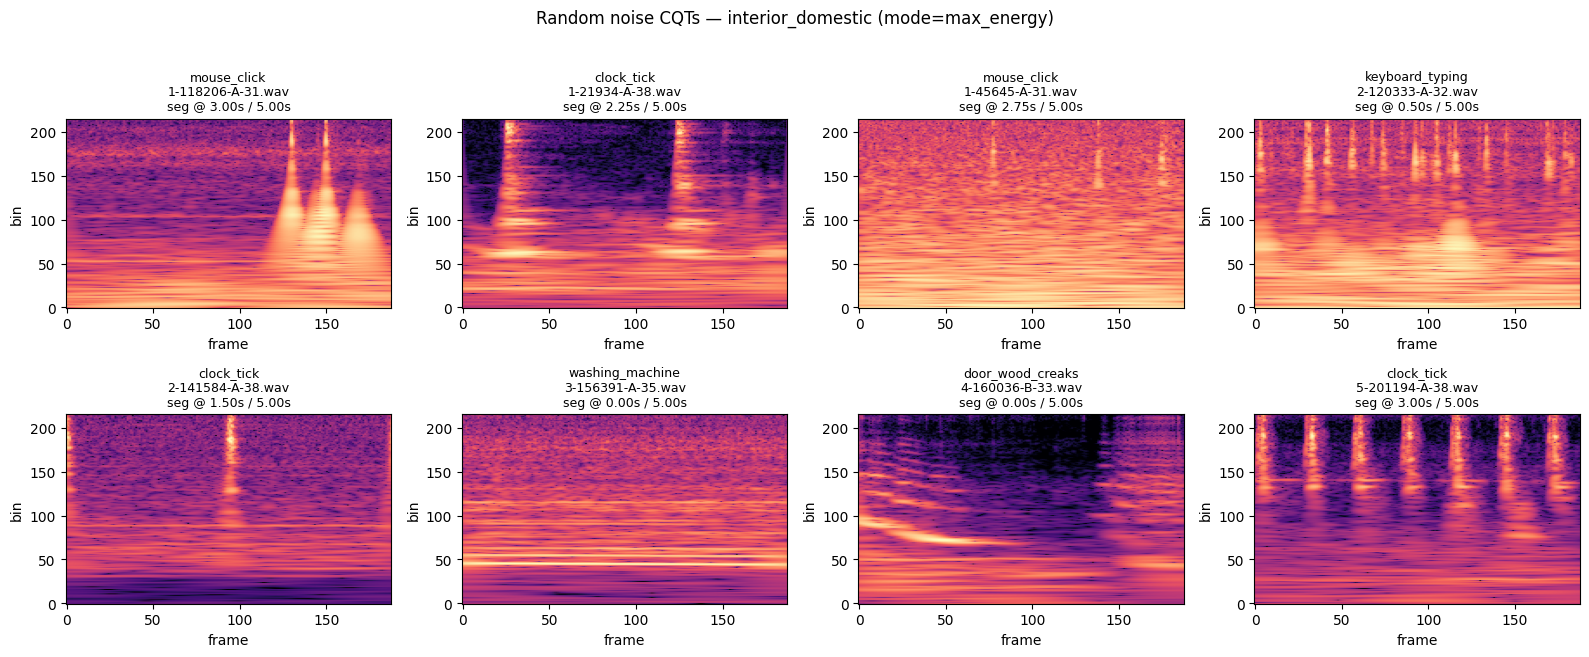

,index,category,file,segment_start_s,duration_s
0,6,mouse_click,1-118206-A-31.wav,3.000000,5.000021
1,16,clock_tick,1-21934-A-38.wav,2.250000,5.000021
2,30,mouse_click,1-45645-A-31.wav,2.750000,5.000021
3,106,keyboard_typing,2-120333-A-32.wav,0.500000,5.000021
4,122,clock_tick,2-141584-A-38.wav,1.500000,5.000021
5,201,washing_machine,3-156391-A-35.wav,0.000000,5.000021
6,250,door_wood_creaks,4-160036-B-33.wav,0.000000,5.000021
7,334,clock_tick,5-201194-A-38.wav,3.000021,5.000021


In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# --- plot config ---
N_SHOW = 8
PLOT_SEED = 0
# None = sample across all classes; or e.g. ["vacuum_cleaner", "keyboard_typing"]
PLOT_CATEGORIES = None

data = np.load(FEATURES_OUT, allow_pickle=True)
features = data["features"]
labels = data["labels"].astype(str)
files = data["files"].astype(str)
starts = data["segment_starts_s"] if "segment_starts_s" in data.files else np.zeros(len(labels))
durations = data["durations_s"] if "durations_s" in data.files else np.full(len(labels), np.nan)

rng = np.random.default_rng(PLOT_SEED)
if PLOT_CATEGORIES is None:
    pool = np.arange(len(labels))
else:
    pool = np.array([i for i, c in enumerate(labels) if c in set(PLOT_CATEGORIES)])
    if len(pool) == 0:
        raise ValueError(f"No samples for PLOT_CATEGORIES={PLOT_CATEGORIES}")

n_show = min(N_SHOW, len(pool))
idx = np.sort(rng.choice(pool, size=n_show, replace=False))

cols = 4
nrows = int(np.ceil(n_show / cols))
fig, axes = plt.subplots(nrows, cols, figsize=(4 * cols, 3.2 * nrows), squeeze=False)

for ax, i in zip(axes.ravel(), idx):
    ax.imshow(features[i], origin="lower", aspect="auto", cmap="magma")
    ax.set_title(
        f"{labels[i]}\n{files[i]}\nseg @ {float(starts[i]):.2f}s / {float(durations[i]):.2f}s",
        fontsize=9,
    )
    ax.set_xlabel("frame")
    ax.set_ylabel("bin")

for ax in axes.ravel()[n_show:]:
    ax.axis("off")

mode = data["segment_mode"] if "segment_mode" in data.files else SEGMENT_MODE
fig.suptitle(f"Random noise CQTs — {BANK_TAG} (mode={mode})", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

shown_df = pd.DataFrame(
    {
        "index": idx,
        "category": labels[idx],
        "file": files[idx],
        "segment_start_s": starts[idx],
        "duration_s": durations[idx],
    }
)
display(shown_df)